✅ Dataset Loaded Successfully!

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural   

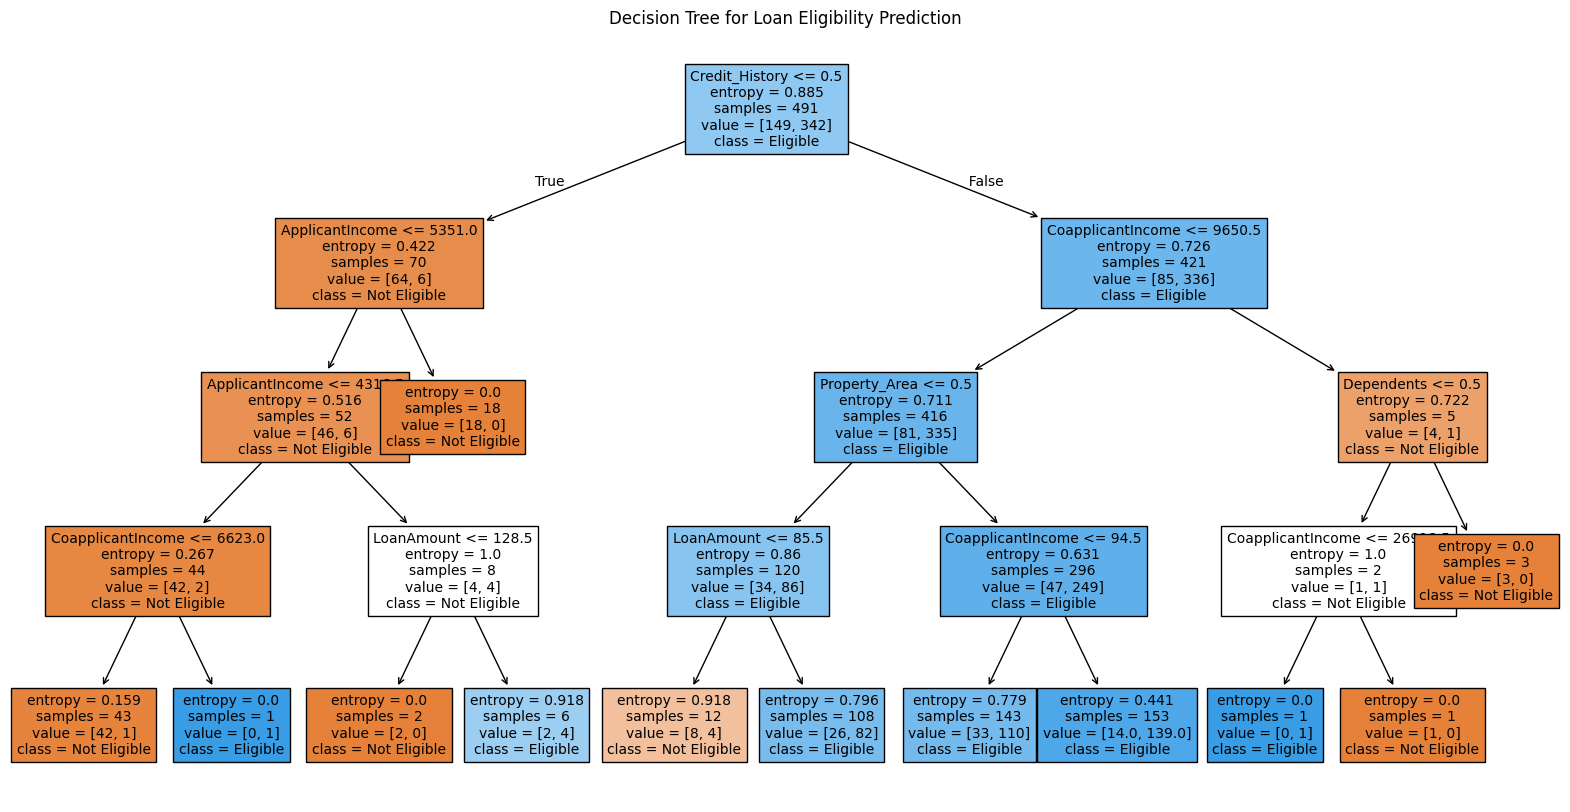

In [2]:
# ===============================
# Decision Tree Classification on Loan Dataset
# ===============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# -------------------------------
# STEP 1: Load Dataset
# -------------------------------
data = pd.read_csv("F:\ML Dataset\Decision Tree, SVM & Naive Bayes Classification\madfhantr.csv")
print("✅ Dataset Loaded Successfully!\n")
print(data.head())

# preprocessing

data['Dependents'] = data['Dependents'].replace('3+', 3).astype(float)

# Fill categorical missing values with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']:
    data[col] = data[col].fillna(data[col].mode()[0])

# Fill numerical missing values with median
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].median())

print("\nMissing values after handling:")
print(data.isnull().sum())

# -------------------------------
# STEP 3: Convert Categorical to Numeric
# -------------------------------
label_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
le = LabelEncoder()

for col in label_cols:
    data[col] = le.fit_transform(data[col])

# -------------------------------
# STEP 4: Define Features and Target
# -------------------------------
X = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = data['Loan_Status']

# -------------------------------
# STEP 5: Split into Train/Test sets
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# STEP 6: Build Decision Tree Model
# -------------------------------
clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# -------------------------------
# STEP 7: Model Evaluation
# -------------------------------
y_pred = clf.predict(X_test)

print("\n🎯 Model Evaluation Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------------
# STEP 8: Visualize Decision Tree
# -------------------------------
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['Not Eligible', 'Eligible'], filled=True, fontsize=10)
plt.title("Decision Tree for Loan Eligibility Prediction")
plt.show()

